In [76]:
import glob
import os

#set current working directory
os.chdir('/home/jovyan')

#list files in shared folder
files = glob.glob("/shared_space/Galveston_Bay/*")
files



['/shared_space/Galveston_Bay/water_temp',
 '/shared_space/Galveston_Bay/MODIS_500',
 '/shared_space/Galveston_Bay/samples.csv',
 '/shared_space/Galveston_Bay/Observed_Temp_Data.csv',
 '/shared_space/Galveston_Bay/Observed_Raw',
 '/shared_space/Galveston_Bay/MODIS_test',
 '/shared_space/Galveston_Bay/MODIS_250',
 '/shared_space/Galveston_Bay/targets.csv',
 '/shared_space/Galveston_Bay/MODIS_files',
 '/shared_space/Galveston_Bay/feature_corr_new.png',
 '/shared_space/Galveston_Bay/Observed_Processed',
 '/shared_space/Galveston_Bay/feature_corr.png',
 '/shared_space/Galveston_Bay/ERA5']

# Ground Truth Data

In [77]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature


###  The Texas Clean Rivers Program  

Guide to Parameter Codes:
https://www.tceq.texas.gov/downloads/water-quality/data-management/reference-guide/dmrg-ch6.pdf

Desciption of Data: 
https://www.h-gac.com/getmedia/1c8428a2-7245-47a2-aac4-84f1ae6dc6d0/Data-Field-Descriptions-and-Use

In [78]:
file_path = "/shared_space/Galveston_Bay/Observed_Raw/all_basin_data_subset.csv"
crp = pd.read_csv(file_path)
crp['End_DateTime'] = pd.to_datetime(
    crp['End_Date'].astype(str).str.strip() + ' ' + crp['End_Time'].astype(str).str.strip(),
    errors='coerce'  # convert invalid entries to NaT instead of error
)
crp=crp[['parameter_code','station_Id','Station_Description','Parameter_Description',
         'Greater_Than_Less_Than','Value','value_adj','End_DateTime','basin_id','LAT_DD','LONG_DD']]

crp_temp=crp[crp['parameter_code']==10]
crp_temp = crp_temp[crp_temp['Greater_Than_Less_Than'] != '<'].copy()

extent = [-95.1, -94.45, 29.29, 29.8]
mask = (
    (crp_temp['LONG_DD'] >= extent[0]) &
    (crp_temp['LONG_DD'] <= extent[1]) &
    (crp_temp['LAT_DD'] >= extent[2]) &
    (crp_temp['LAT_DD'] <= extent[3])
)
crp_temp = crp_temp[mask]

/opt/conda/lib/python3.7/site-packages/IPython/core/interactiveshell.py:3058: DtypeWarning:

Columns (5,10,11,13,33,38,44,50) have mixed types. Specify dtype option on import or set low_memory=False.



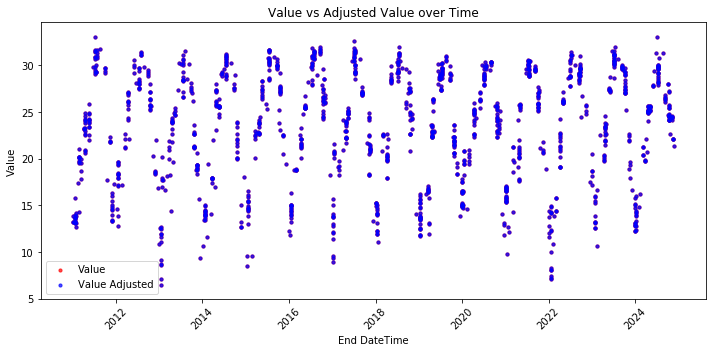

In [79]:
# QC check
x = mdates.date2num(crp_temp['End_DateTime'])
y1 = crp_temp['Value']
y2 = crp_temp['value_adj']

plt.figure(figsize=(10, 5))
plt.scatter(x, y1, s=10, alpha=0.7, c='red', label='Value')
plt.scatter(x, y2, s=10, alpha=0.7, c='blue', label='Value Adjusted')
ax = plt.gca()
ax.xaxis_date()
plt.xlabel('End DateTime')
plt.ylabel('Value')
plt.title('Value vs Adjusted Value over Time')
plt.xticks(rotation=45)
plt.legend()              
plt.tight_layout()
plt.show()

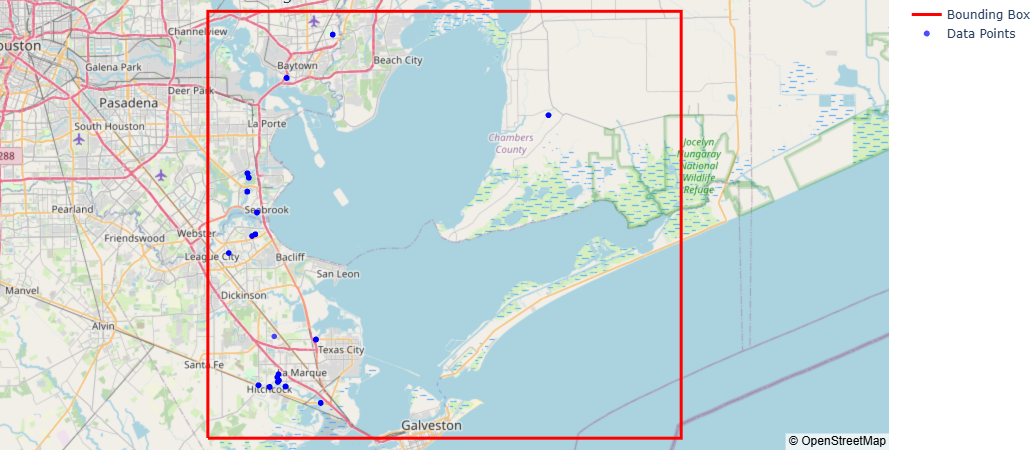

In [80]:
import plotly.graph_objects as go

# Bounding box
extent = [-95.1, -94.45, 29.29, 29.8]
lons = [extent[0], extent[1], extent[1], extent[0], extent[0]]
lats = [extent[2], extent[2], extent[3], extent[3], extent[2]]

# Center of the bounding box
center_lon = (extent[0] + extent[1]) / 2
center_lat = (extent[2] + extent[3]) / 2

fig = go.Figure()

# Add bounding box
fig.add_trace(go.Scattermapbox(
    lon=lons,
    lat=lats,
    mode='lines',
    line=dict(width=3, color='red'),
    name='Bounding Box'
))


# Add data points
fig.add_trace(go.Scattermapbox(
    lon=crp_DO['LONG_DD'],
    lat=crp_DO['LAT_DD'],
    mode='markers',
    marker=dict(size=6, color='blue', opacity=0.7),
    name='Data Points'
))

# Update layout
fig.update_layout(
    mapbox=dict(
        style="open-street-map",
        center=dict(lat=center_lat, lon=center_lon),
        zoom=9
    ),
    margin={"r":0,"t":0,"l":0,"b":0},
    title="Data Points within Bounding Box"
)

fig.show()


###  The Texas Stream Team

In [81]:
file_path = "/shared_space/Galveston_Bay/Observed_Raw/TST_Monitoring_Data_May2025_for_HGAC_Website.xlsx"
st = pd.read_excel(file_path)

st=st[['Location','LATITUDE','LONGITUDE','Sample_Date','Air_Temperature','Water_Temperature','DO']]
st['DO'] = pd.to_numeric(st['DO'], errors='coerce')
st = st.dropna(subset=['DO']).copy()
st=st[st['DO']<20]
st=st[st['Sample_Date'].dt.year>=2010]

extent = [-95.1, -94.45, 29.29, 29.8]
mask = (
    (st['LONGITUDE'] >= extent[0]) &
    (st['LONGITUDE'] <= extent[1]) &
    (st['LATITUDE'] >= extent[2]) &
    (st['LATITUDE'] <= extent[3])
)
st = st[mask]

st.head()

,Location,LATITUDE,LONGITUDE,Sample_Date,Air_Temperature,Water_Temperature,DO
21,Clear Creek at N Egret Bay Blvd,29.534689,-95.095329,2025-01-07,4.5,4.5,8.2
23,"Armand Bayou Nature Center, May's Pond",29.607305,-95.083123,2010-11-27,7.0,4.5,6.4
37,Taylor Lake at NASA Parkway,29.565576,-95.054155,2011-02-03,4.0,6.0,10.8
62,Moses Lake at Texas City Prairie Preserve,29.428815,-94.950463,2012-02-28,17.0,7.0,6.6
64,Moses Lake at Texas City Prairie Preserve,29.428815,-94.950463,2012-01-03,6.5,7.5,8.8


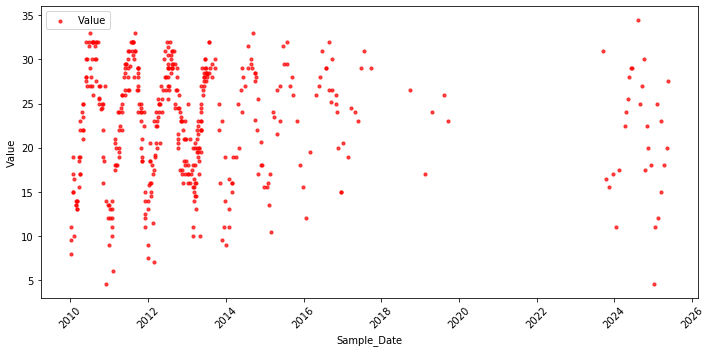

In [82]:
x = mdates.date2num(st['Sample_Date'])
y1 = st['Water_Temperature']

plt.figure(figsize=(10, 5))
plt.scatter(x, y1, s=10, alpha=0.7, c='red', label='Value')
ax = plt.gca()
ax.xaxis_date()
plt.xlabel('Sample_Date')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.legend()              
plt.tight_layout()
plt.show()

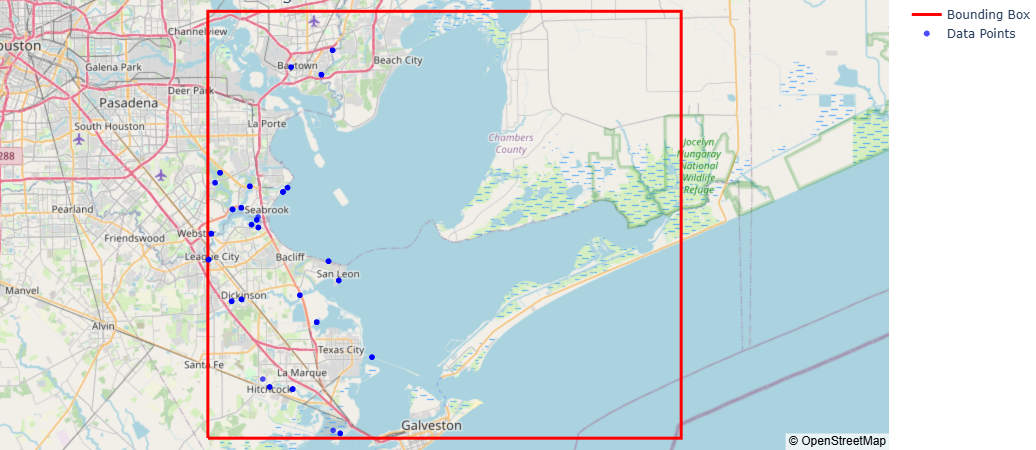

In [83]:

fig = go.Figure()

# Add bounding box
fig.add_trace(go.Scattermapbox(
    lon=lons,
    lat=lats,
    mode='lines',
    line=dict(width=3, color='red'),
    name='Bounding Box'
))


# Add data points
fig.add_trace(go.Scattermapbox(
    lon=st['LONGITUDE'],
    lat=st['LATITUDE'],
    mode='markers',
    marker=dict(size=6, color='blue', opacity=0.7),
    name='Data Points'
))

# Update layout
fig.update_layout(
    mapbox=dict(
        style="open-street-map",
        center=dict(lat=center_lat, lon=center_lon),
        zoom=9
    ),
    margin={"r":0,"t":0,"l":0,"b":0},
    title="Data Points within Bounding Box"
)

fig.show()


### National Water Quality Portal (Also Stream Team?)

In [84]:
file_path = "/shared_space/Galveston_Bay/Observed_Raw/resultphyschem_temp4.csv"
nwq = pd.read_csv(file_path)
nwq.head()

nwq['ResultMeasureValue'] = pd.to_numeric(nwq['ResultMeasureValue'], errors='coerce')

extent = [-95.1, -94.45, 29.29, 29.8]
mask = (
    (nwq['ActivityLocation/LongitudeMeasure'] >= extent[0]) &
    (nwq['ActivityLocation/LongitudeMeasure'] <= extent[1]) &
    (nwq['ActivityLocation/LatitudeMeasure'] >= extent[2]) &
    (nwq['ActivityLocation/LatitudeMeasure'] <= extent[3])
)
nwq = nwq[mask]

nwq['DateTime'] = pd.to_datetime(
    nwq['ActivityStartDate'].astype(str).str.strip() ,
    errors='coerce'  # convert invalid entries to NaT instead of error
)

nwq.CharacteristicName.unique()

array(['Temperature, sample', 'Temperature, water'], dtype=object)

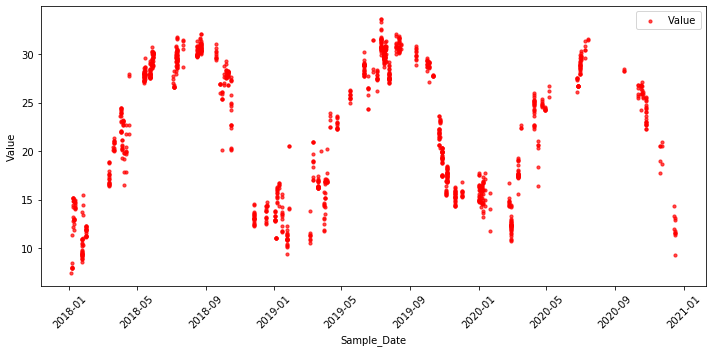

In [85]:
x = mdates.date2num(nwq['DateTime'])
y1 = nwq['ResultMeasureValue']

plt.figure(figsize=(10, 5))
plt.scatter(x, y1, s=10, alpha=0.7, c='red', label='Value')
ax = plt.gca()
ax.xaxis_date()
plt.xlabel('Sample_Date')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.legend()              
plt.tight_layout()
plt.show()

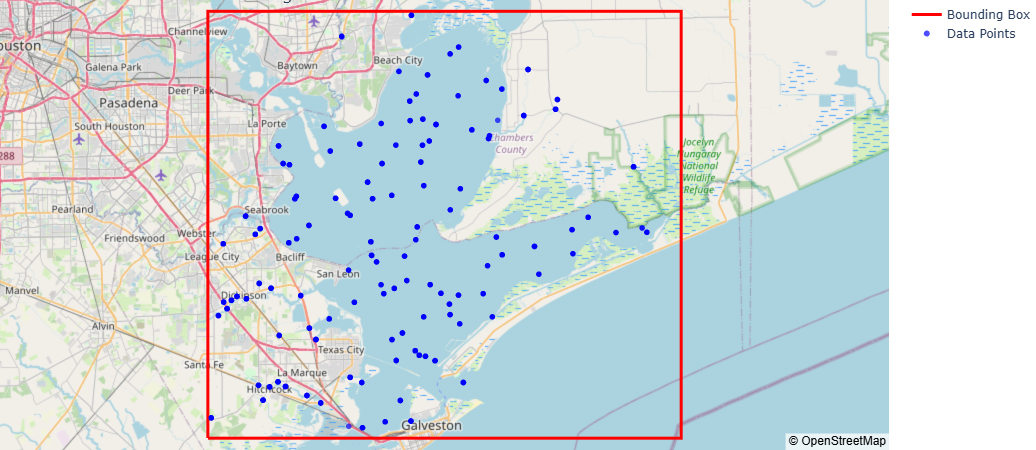

In [86]:

fig = go.Figure()

# Add bounding box
fig.add_trace(go.Scattermapbox(
    lon=lons,
    lat=lats,
    mode='lines',
    line=dict(width=3, color='red'),
    name='Bounding Box'
))


# Add data points
fig.add_trace(go.Scattermapbox(
    lon=nwq['ActivityLocation/LongitudeMeasure'],
    lat=nwq['ActivityLocation/LatitudeMeasure'],
    mode='markers',
    marker=dict(size=6, color='blue', opacity=0.7),
    name='Data Points'
))

# Update layout
fig.update_layout(
    mapbox=dict(
        style="open-street-map",
        center=dict(lat=center_lat, lon=center_lon),
        zoom=9
    ),
    margin={"r":0,"t":0,"l":0,"b":0},
    title="Data Points within Bounding Box"
)

fig.show()


### Galveston Bay Regional Monitoring Database

In [87]:
stations_file="/shared_space/Galveston_Bay/Observed_Raw/SWQM_Stations.csv"
stations=pd.read_csv(stations_file)
stations=stations[['STATION_ID','LAT_DD','LONG_DD']]

stations = (
    stations.rename(columns={
        'STATION_ID': 'Station_ID',
        'LAT_DD': 'lat',
        'LONG_DD': 'lon'
    }))


In [88]:
file_path = "/shared_space/Galveston_Bay/Observed_Raw/RMD_Combined_Field.csv"
RMD = pd.read_csv(file_path)
RMD = (
    RMD.rename(columns={
        'Station_Sample_ID': 'Station_ID',
    }))

RMD['End_DateTime'] = pd.to_datetime(
    RMD['End_Date'].astype(str).str.strip() + ' ' + RMD['End_Time'].astype(str).str.strip(),
    errors='coerce'  # convert invalid entries to NaT instead of error
)

RMD_w_coord = pd.merge(RMD, stations, on='Station_ID')
RMD_w_coord.head()
#RMD_w_coord=RMD_w_coord[['Station_ID','Value','lat', 'lon','End_DateTime']]

extent = [-95.1, -94.45, 29.29, 29.8]
mask = (
    (RMD_w_coord['lon'] >= extent[0]) &
    (RMD_w_coord['lon'] <= extent[1]) &
    (RMD_w_coord['lat'] >= extent[2]) &
    (RMD_w_coord['lat'] <= extent[3])
)
RMD_w_coord = RMD_w_coord[mask]
RMD_w_coord=RMD_w_coord[RMD_w_coord['End_DateTime'].dt.year>=2010]
RMD_w_coord=RMD_w_coord[RMD_w_coord['Alt_Par_Desc']=='TEMPERATURE, WATER (DEGREES CENTIGRADE)']
RMD_w_coord=RMD_w_coord[['Station_ID','Value','lat', 'lon','End_DateTime']]


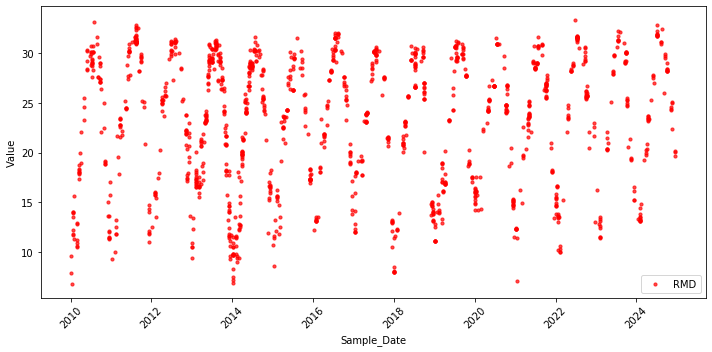

In [89]:
x = mdates.date2num(RMD_w_coord['End_DateTime'])
y = RMD_w_coord['Value']

plt.figure(figsize=(10, 5))
plt.scatter(x, y, s=10, alpha=0.7, c='red', label='RMD')
ax = plt.gca()
ax.xaxis_date()
plt.xlabel('Sample_Date')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.legend()              
plt.tight_layout()
plt.show()

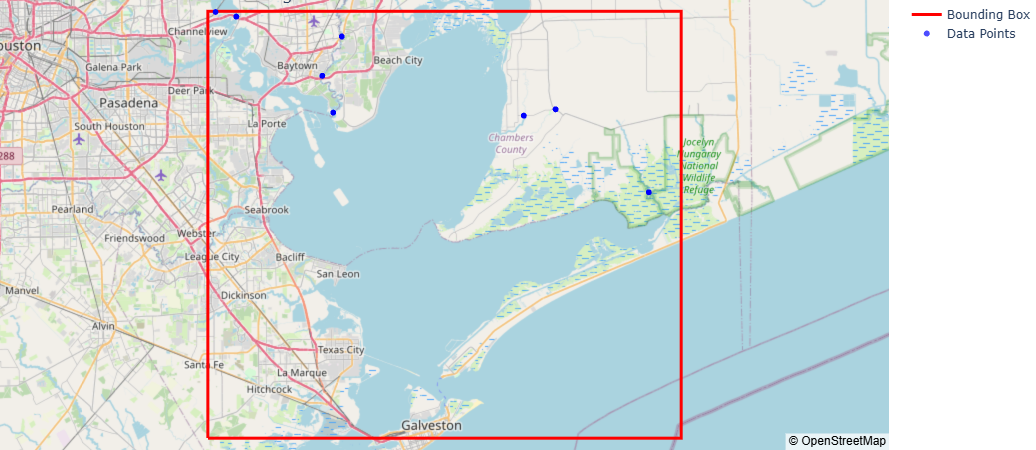

In [90]:

fig = go.Figure()

# Add bounding box
fig.add_trace(go.Scattermapbox(
    lon=lons,
    lat=lats,
    mode='lines',
    line=dict(width=3, color='red'),
    name='Bounding Box'
))


# Add data points
fig.add_trace(go.Scattermapbox(
    lon=RMD_w_coord['lon'],
    lat=RMD_w_coord['lat'],
    mode='markers',
    marker=dict(size=6, color='blue', opacity=0.7),
    name='Data Points'
))

# Update layout
fig.update_layout(
    mapbox=dict(
        style="open-street-map",
        center=dict(lat=center_lat, lon=center_lon),
        zoom=9
    ),
    margin={"r":0,"t":0,"l":0,"b":0},
    title="Data Points within Bounding Box"
)

fig.show()


# Combine

In [91]:
# Clean crp_DO
crp_temp_clean = (
    crp_temp.rename(columns={
        'End_DateTime': 'DateTime',
        'Value': 'Value',
        'LAT_DD': 'lat',
        'LONG_DD': 'lon'
    })[['DateTime', 'Value', 'lat', 'lon']].copy()
)

# Clean st
st_clean = (
    st.rename(columns={
        'Sample_Date': 'DateTime',
        'Water_Temperature': 'Value',
        'LATITUDE': 'lat',
        'LONGITUDE': 'lon'
    })[['DateTime', 'Value', 'lat', 'lon']].copy()
)

# clean nwp
nwq_clean = (
    nwq.rename(columns={
        'ResultMeasureValue': 'Value',
        'ActivityLocation/LatitudeMeasure': 'lat',
        'ActivityLocation/LongitudeMeasure': 'lon'
    })[['DateTime', 'Value', 'lat', 'lon']].copy()
)
# Clean RMD
RMD_clean = (
    RMD_w_coord.rename(columns={
        'End_DateTime': 'DateTime',
    })[['DateTime', 'Value', 'lat', 'lon']].copy()
)

crp_temp_clean['source'] = 'Clean Rivers Program'
st_clean['source'] = 'Stream Team'
RMD_clean['source']='Regional Monitoring Database'
nwq_clean['source']='Water Quality Portal'

combined_df = pd.concat([crp_temp_clean, st_clean,RMD_clean,nwq_clean], ignore_index=True)
combined_df = combined_df.sort_values('DateTime').reset_index(drop=True)
combined_df['Value'] = pd.to_numeric(combined_df['Value'], errors='coerce')

combined_df = combined_df.drop_duplicates().reset_index(drop=True)

combined_df.dtypes

DateTime    datetime64[ns]
Value              float64
lat                float64
lon                float64
source              object
dtype: object

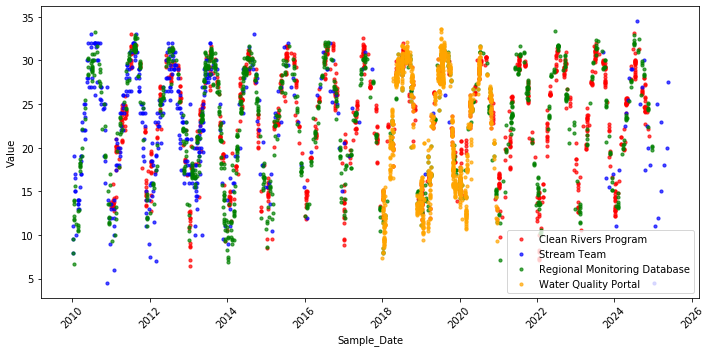

In [92]:
x = mdates.date2num(combined_df['DateTime'])
y = combined_df['Value']

plt.figure(figsize=(10, 5))
ax = plt.gca()
ax.xaxis_date()

# Define colors for each source
colors = {'Clean Rivers Program': 'red', 'Stream Team': 'blue','Regional Monitoring Database':'green','Water Quality Portal':'orange'}

# Plot each source separately
for src, color in colors.items():
    mask = combined_df['source'] == src
    plt.scatter(x[mask], y[mask], s=10, alpha=0.7, c=color, label=src)

plt.xlabel('Sample_Date')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

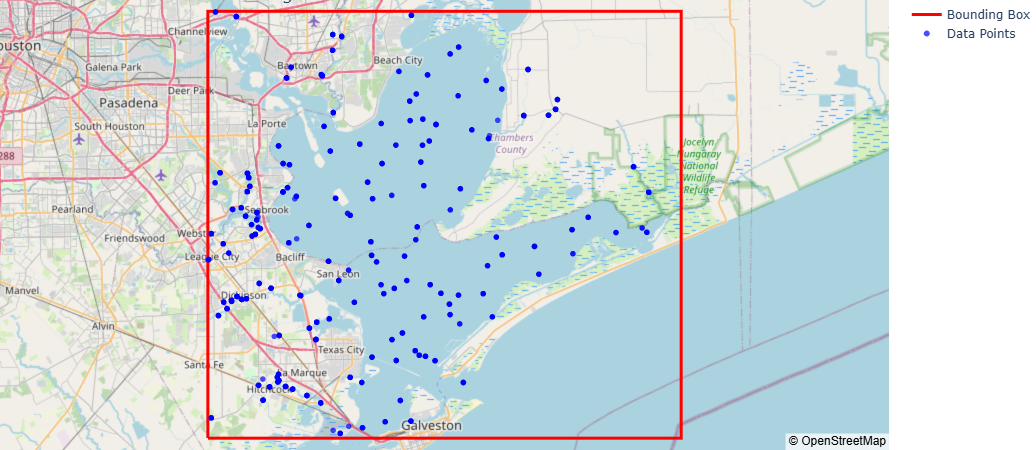

In [93]:

fig = go.Figure()

# Add bounding box
fig.add_trace(go.Scattermapbox(
    lon=lons,
    lat=lats,
    mode='lines',
    line=dict(width=3, color='red'),
    name='Bounding Box'
))


# Add data points
fig.add_trace(go.Scattermapbox(
    lon=combined_df['lon'],
    lat=combined_df['lat'],
    mode='markers',
    marker=dict(size=6, color='blue', opacity=0.7),
    name='Data Points'
))

# Update layout
fig.update_layout(
    mapbox=dict(
        style="open-street-map",
        center=dict(lat=center_lat, lon=center_lon),
        zoom=9
    ),
    margin={"r":0,"t":0,"l":0,"b":0},
    title="Data Points within Bounding Box"
)

fig.show()


In [95]:


combined_df.to_csv('/shared_space/Galveston_Bay/Observed_Processed/Observed_Temp_Data.csv', index=False)